Found 50 triplets with tile + index + polygon


Epoch 1/10: 100%|██████████| 10/10 [00:29<00:00,  2.98s/it]


Epoch 1 - Train Loss: 0.3581


Epoch 2/10: 100%|██████████| 10/10 [00:29<00:00,  2.95s/it]


Epoch 2 - Train Loss: 0.2444


...

Epoch 9/10: 100%|██████████| 10/10 [00:32<00:00,  3.23s/it]


Epoch 9 - Train Loss: 0.1418


Epoch 10/10: 100%|██████████| 10/10 [00:32<00:00,  3.24s/it]


Epoch 10 - Train Loss: 0.1695


Inference: 100%|██████████| 3/3 [00:10<00:00,  3.37s/it]


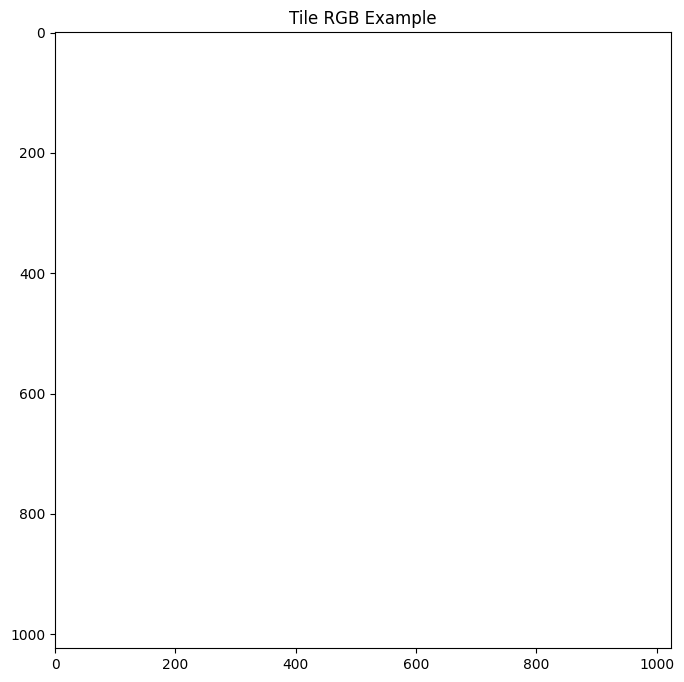

In [19]:
# pipeline_silo_notebook.py
# Pipeline mínimo para entrenamiento de U-Net en tiles RGB+NIR
# CPU-friendly, Windows, debug con subset
# Requisitos: rasterio, geopandas, shapely, tqdm, numpy, torch, torchvision, sklearn, matplotlib, albumentations, scipy

# --- CONFIG -------------------------------------------------------------------
TILES_DIR = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles"
INDICES_DIR = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV"
POLYGONS_DIR = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
OUT_DIR = r"C:\Users\m\Documents\Tesis_Silos\Silos_FR_MCDtf\Notebooks\training_output"

DEBUG_USE_SUBSET = True
SUBSET_SIZE = 50
CHANNELS = ['R','G','B','NIR']

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
VAL_SPLIT = 0.2
DEVICE = 'cpu'
PRED_THRESHOLD = 0.5

MIN_COMPONENT_SIZE_PX = 9
FILTER_SMALL_POLYGONS = True
CLIP_GRAD_NORM = 2.0

os.makedirs(OUT_DIR, exist_ok=True)

# --- DEPENDENCIAS -------------------------------------------------------------
import os, glob, random
from pathlib import Path
import numpy as np
import rasterio
from rasterio.features import rasterize, shapes
import geopandas as gpd
from shapely.geometry import box, shape
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy import ndimage

# -------------------- Helpers -------------------------------------------------
def base_prefix_from_tile(path):
    return Path(path).stem.replace('.tif','')

# Listar tiles y filtrar subset
all_tiles = sorted(glob.glob(os.path.join(TILES_DIR, "*_tile_*.tif")))
tiles = all_tiles[:SUBSET_SIZE] if DEBUG_USE_SUBSET else all_tiles

pairs = []
for t in tiles:
    base = Path(t).stem
    idx_path = os.path.join(INDICES_DIR, base + "_INBNV.tif")
    shp_path_glob = os.path.join(POLYGONS_DIR, base + "*_PERCENTILE_POLYGONS.shp")
    shps = glob.glob(shp_path_glob)
    shp_path = shps[0] if len(shps)>0 else None
    if os.path.exists(idx_path) and shp_path is not None:
        pairs.append((t, idx_path, shp_path))

print(f"Found {len(pairs)} triplets with tile + index + polygon")

# -------------------- Rasterizar shapefile -----------------------------------
def rasterize_polygons_to_mask(tile_path, shp_path, min_component_px=MIN_COMPONENT_SIZE_PX):
    with rasterio.open(tile_path) as src:
        transform, h, w, crs = src.transform, src.height, src.width, src.crs

    gdf = gpd.read_file(shp_path)
    if gdf.empty:
        return np.zeros((h,w), dtype=np.uint8)

    if gdf.crs != crs:
        gdf = gdf.to_crs(crs)

    if FILTER_SMALL_POLYGONS:
        bounds = gdf.geometry.bounds
        gdf['bbox_area'] = (bounds['maxx'] - bounds['minx']) * (bounds['maxy'] - bounds['miny'])
        gdf = gdf[gdf['bbox_area']>0.0001]
        if gdf.empty:
            return np.zeros((h,w), dtype=np.uint8)

    shapes_list = [(geom,1) for geom in gdf.geometry if geom is not None]
    if len(shapes_list)==0:
        return np.zeros((h,w), dtype=np.uint8)

    mask = rasterize(shapes_list, out_shape=(h,w), transform=transform, fill=0, dtype='uint8')

    # eliminar componentes pequeños
    labels, ncomp = ndimage.label(mask)
    if ncomp>0:
        counts = np.bincount(labels.flatten())
        remove_labels = np.where(counts<min_component_px)[0]
        for rl in remove_labels:
            if rl==0: continue
            mask[labels==rl]=0

    return mask.astype(np.uint8)

# -------------------- Dataset -------------------------------------------------
class SiloTilesDataset(Dataset):
    def __init__(self, pairs, channels=['R','G','B','NIR'], img_size=256, mode='train'):
        self.pairs = pairs
        self.channels = channels
        self.img_size = img_size
        self.mode = mode

    def __len__(self):
        return len(self.pairs)

    def read_tile(self, path):
        with rasterio.open(path) as src:
            arr = src.read().astype('float32')
            nod = src.nodata
            if nod is not None:
                arr[arr==nod] = np.nan
            return arr

    def __getitem__(self, idx):
        tile_path, idx_path, shp_path = self.pairs[idx]
        arr = self.read_tile(tile_path)

        ch_map = {'R':0,'G':1,'B':2,'NIR':3}
        selected, valid_mask = [], None
        for c in self.channels:
            bi = ch_map.get(c, None)
            band = arr[bi] if bi is not None and bi<arr.shape[0] else np.zeros((arr.shape[1], arr.shape[2]), dtype=np.float32)
            selected.append(band)
            finite = np.isfinite(band)
            valid_mask = finite if valid_mask is None else valid_mask & finite

        selected = [np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32) for b in selected]
        img = np.stack(selected, axis=0)

        mask = rasterize_polygons_to_mask(tile_path, shp_path).astype(np.uint8)

        # crop/pad
        C,H,W = img.shape
        if H>self.img_size or W>self.img_size:
            top = random.randint(0, H-self.img_size) if self.mode=='train' else (H-self.img_size)//2
            left = random.randint(0, W-self.img_size) if self.mode=='train' else (W-self.img_size)//2
            img = img[:, top:top+self.img_size, left:left+self.img_size]
            mask = mask[top:top+self.img_size, left:left+self.img_size]
            valid_mask = valid_mask[top:top+self.img_size, left:left+self.img_size]
        else:
            pad_h, pad_w = max(0,self.img_size-H), max(0,self.img_size-W)
            if pad_h>0 or pad_w>0:
                img = np.pad(img, ((0,0),(0,pad_h),(0,pad_w)), mode='constant')
                mask = np.pad(mask, ((0,pad_h),(0,pad_w)), mode='constant')
                valid_mask = np.pad(valid_mask, ((0,pad_h),(0,pad_w)), mode='constant')

        img -= img.min()
        img /= (img.max()+1e-6)

        if self.mode=='train':
            if random.random()<0.5:
                img = np.flip(img, axis=2).copy()
                mask = np.flip(mask, axis=1).copy()
                valid_mask = np.flip(valid_mask, axis=1).copy()
            if random.random()<0.5:
                img = np.flip(img, axis=1).copy()
                mask = np.flip(mask, axis=0).copy()
                valid_mask = np.flip(valid_mask, axis=0).copy()

        return torch.from_numpy(img).float(), torch.from_numpy(mask).unsqueeze(0).float(), torch.from_numpy(valid_mask.astype(np.uint8)).unsqueeze(0).float(), tile_path

# -------------------- U-Net pequeña ------------------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=4, out_ch=1, base=32):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.dconv_down2 = DoubleConv(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.dconv_down3 = DoubleConv(base*2, base*4)
        self.up3 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dconv_up3 = DoubleConv(base*4, base*2)
        self.up2 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dconv_up2 = DoubleConv(base*2, base)
        self.conv_last = nn.Conv2d(base, out_ch, 1)
    def forward(self, x):
        c1 = self.dconv_down1(x)
        c2 = self.dconv_down2(self.pool1(c1))
        c3 = self.dconv_down3(self.pool2(c2))
        u3 = self.up3(c3)
        u3 = self.dconv_up3(torch.cat([u3,c2], dim=1))
        u2 = self.up2(u3)
        u2 = self.dconv_up2(torch.cat([u2,c1], dim=1))
        out = self.conv_last(u2)
        return torch.sigmoid(out)

# -------------------- Train / Val split --------------------------------------
train_pairs, val_pairs = train_test_split(pairs, test_size=VAL_SPLIT, random_state=42)
train_ds = SiloTilesDataset(train_pairs, channels=CHANNELS, img_size=IMG_SIZE, mode='train')
val_ds = SiloTilesDataset(val_pairs, channels=CHANNELS, img_size=IMG_SIZE, mode='val')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# -------------------- Entrenamiento ------------------------------------------
model = UNetSmall(in_ch=len(CHANNELS)).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for imgs, masks, valid_mask, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        imgs, masks, valid_mask = imgs.to(DEVICE), masks.to(DEVICE), valid_mask.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out*valid_mask, masks*valid_mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss/len(train_loader):.4f}")

# -------------------- Inferencia + Guardado ----------------------------------
pred_dir = os.path.join(OUT_DIR, 'predictions')
os.makedirs(pred_dir, exist_ok=True)

model.eval()
with torch.no_grad():
    for imgs, masks, valid_mask, tile_paths in tqdm(val_loader, desc="Inference"):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).cpu().numpy()
        for i in range(imgs.size(0)):
            mask_pred = (preds[i,0]>PRED_THRESHOLD).astype(np.uint8)
            tile_path = tile_paths[i]
            out_mask_path = os.path.join(pred_dir, Path(tile_path).stem + '_predmask.tif')

            with rasterio.open(tile_path) as src:
                meta = src.meta.copy()
            meta.update({'count':1, 'dtype':'uint8', 'nodata':0})
            with rasterio.open(out_mask_path, 'w', **meta) as dst:
                dst.write(mask_pred, 1)

            # Guardar shapefile
            polygons = [shape(geom) for geom,_ in shapes(mask_pred, transform=meta['transform'])]
            gdf = gpd.GeoDataFrame({'geometry':polygons}, crs=meta['crs'])
            shp_out = os.path.join(pred_dir, Path(tile_path).stem + '_predmask.shp')
            gdf.to_file(shp_out)

# -------------------- Visualización de ejemplo --------------------------------
tile_path, _, _ = val_pairs[0]
ds = rasterio.open(tile_path)
img = np.stack([ds.read(i+1) for i in range(len(CHANNELS))], axis=0)
img = (img - img.min()) / (img.max()-img.min()+1e-6)
plt.figure(figsize=(8,8))
plt.imshow(np.transpose(img[:3,:,:], (1,2,0)))
plt.title("Tile RGB Example")
plt.show()


In [21]:
import matplotlib.pyplot as plt
plt.imshow(np.transpose(tile, (1, 2, 0)))  # cambiar a (H, W, 3)
plt.title("Tile RGB Example")
plt.show()



NameError: name 'tile' is not defined